<a href="https://colab.research.google.com/github/Chaotic-Legend/CMP-415-Codes/blob/main/Midterm%20Project%20Part%201%3A%20Analyzing%20the%20Demand%20for%20Bike%20Sharing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Midterm Project Part 1: Analyzing the Demand for Bike Sharing
#### CMP 415: Machine Learning - Isaac D. Hoyos

Bike-sharing systems are a means of renting bicycles, with the processes of obtaining membership, renting a bike, and returning it automated through a network of kiosks throughout a city. Using these systems, people can rent a bike from one location and return it to another on an as-needed basis. Currently, there are over 500 bike-sharing programs worldwide.

For this project, we will explore a dataset from Capital Bikeshare, a bike-sharing program in Washington, D.C. It is interesting to discover the bike usage patterns in relation to weather conditions and the nature of the day.

# I. Acquire the Dataset

1. Download the data `Bike-Sharing-Dataset.zip` file from [Bike Sharing dataset in the Machine Learning Repository at UC Irvine](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset). Unzip the file to obtain the file `day.csv`. Read the description of the dataset to learn the meaning of values in each column.

In [1]:
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

zip_filename = "bike+sharing+dataset.zip"
csv_filename = "day.csv"

# Check whether the day.csv file already exists in the current environment.
if not os.path.exists(csv_filename):
    print(f"⬆️ Please upload the \"{zip_filename}\" file...\n")
    while True:
        uploaded = files.upload()

        # We retrieve the name of the uploaded file.
        uploaded_filename = list(uploaded.keys())[0]

        # We verify whether the uploaded file matches the expected ZIP file.
        if uploaded_filename == zip_filename:
            print(f"\n✅ File \"{zip_filename}\" has been uploaded successfully!")

            # Extract the day.csv data from the ZIP file.
            with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
                if csv_filename in zip_ref.namelist():
                    zip_ref.extract(csv_filename)
                    print(f"\n📂 File \"{csv_filename}\" has been extracted successfully!")
                    break
                else:
                    print(f"\n❌ Error: \"{csv_filename}\" was not found inside the ZIP file.\n")
        else:
            print(f"\n❌ Error: Please upload the correct \"{zip_filename}\" file...\n")
else:
    print(f"✅ Using the existing \"{csv_filename}\" file.")

⬆️ Please upload the "bike+sharing+dataset.zip" file...



Saving bike+sharing+dataset.zip to bike+sharing+dataset.zip

✅ File "bike+sharing+dataset.zip" has been uploaded successfully!

📂 File "day.csv" has been extracted successfully!


2. Load the data from the `day.csv` file as a Pandas data frame. Display its first 5 rows to confirm that the data is loaded correctly.

In [2]:
# Load the day.csv file into a data frame.
df = pd.read_csv(csv_filename)

# Display the first 5 rows to confirm that the data is loaded.
print("=== First 5 Rows of the day.csv DataFrame ===")
df.head()

=== First 5 Rows of the day.csv DataFrame ===


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


3. Display the shape of the data frame.

In [3]:
print("=== Shape of the day.csv DataFrame ===")
df.shape

=== Shape of the day.csv DataFrame ===


(731, 16)

4. Display the data type of each column.

In [4]:
print("=== Data Type of Each Column ===")
df.dtypes

=== Data Type of Each Column ===


,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64


5. The default data type for 'dteday' is `object`. Use [pd.to_datetime](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) to convert it to `datetime` type. After the conversion, display the data types again to confirm that the conversion is successful.

In [5]:
# Convert the 'dteday' column to datetime and display the updated data types.
df['dteday'] = pd.to_datetime(df['dteday'])
print("=== Data Type of Each Column After Conversion ===")
df.dtypes

=== Data Type of Each Column After Conversion ===


,0
instant,int64
dteday,datetime64[ns]
season,int64
yr,int64
mnth,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64


6. Create a new column 'year' by extracting the year value from the datetime of each row.

In [6]:
# Extract the year value from the datetime of each row.
df['year'] = df['dteday'].dt.year
print("=== Year Column Extracted From Each Row ===")
df[['dteday', 'year']]

=== Year Column Extracted From Each Row ===


,dteday,year
0,2011-01-01,2011
1,2011-01-02,2011
2,2011-01-03,2011
3,2011-01-04,2011
4,2011-01-05,2011
...,...,...
726,2012-12-27,2012
727,2012-12-28,2012
728,2012-12-29,2012
729,2012-12-30,2012


7. Remove the "casual" column and the "registered" column, as we are solely interested in the total number of bike rentals, which is given in the "cnt" column. Also, remove the following columns: 'instant', 'yr', and 'atemp'. Display the first 5 rows again to confirm the removal of these columns.

In [7]:
# Remove the unnecessary columns from the data frame.
df = df.drop(columns=['casual', 'registered', 'instant', 'yr', 'atemp'])
print("=== Columns After Removing Unnecessary Fields ===")
print(df.columns)
print("\n=== First 5 Rows of the Updated day.csv DataFrame ===")
df.head()

=== Columns After Removing Unnecessary Fields ===
Index(['dteday', 'season', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'hum', 'windspeed', 'cnt', 'year'],
      dtype='object')

=== First 5 Rows of the Updated day.csv DataFrame ===


,dteday,season,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt,year
0,2011-01-01,1,1,0,6,0,2,0.344167,0.805833,0.160446,985,2011
1,2011-01-02,1,1,0,0,0,2,0.363478,0.696087,0.248539,801,2011
2,2011-01-03,1,1,0,1,1,1,0.196364,0.437273,0.248309,1349,2011
3,2011-01-04,1,1,0,2,1,1,0.200000,0.590435,0.160296,1562,2011
4,2011-01-05,1,1,0,3,1,1,0.226957,0.436957,0.186900,1600,2011


8. Display the number of missing values from each column.

In [8]:
print("=== Number of Missing Values From Each Column ===")
df.isnull().sum()

=== Number of Missing Values From Each Column ===


,0
dteday,0
season,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0
hum,0
windspeed,0


## II. Data Exploration

1. The season feature: split the data frame into four subsets according to the season value. You may call them `data_spring`, `data_summer`, `data_fall`, and `data_winter`. Calculate and display the average number of bike rentals for each season.

In [9]:
# Split the data frame into the four seasons.
data_spring = df[df['season'] == 1]
data_summer = df[df['season'] == 2]
data_fall   = df[df['season'] == 3]
data_winter = df[df['season'] == 4]

# Calculate the average bike rentals for each season.
print("=== Average Bike Rentals for Each Season ===")
print("Average Bike Rentals in Spring:", data_spring['cnt'].mean())
print("\nAverage Bike Rentals in Summer:", data_summer['cnt'].mean())
print("\nAverage Bike Rentals in Fall:", data_fall['cnt'].mean())
print("\nAverage Bike Rentals in Winter:", data_winter['cnt'].mean())

=== Average Bike Rentals for Each Season ===
Average Bike Rentals in Spring: 2604.1325966850827

Average Bike Rentals in Summer: 4992.33152173913

Average Bike Rentals in Fall: 5644.303191489362

Average Bike Rentals in Winter: 4728.162921348315


2. The 'holiday' feature: calculate and display the average bike rentals for holidays and non-holidays, separately.

In [10]:
# Calculate the average bike rentals for holidays and non-holidays.
holiday_avg = df[df['holiday'] == 1]['cnt'].mean()
nonholiday_avg = df[df['holiday'] == 0]['cnt'].mean()
print("=== Average Bike Rentals for Holidays and Non-Holidays ===")
print("Average Bike Rentals on Holidays:", holiday_avg)
print("\nAverage Bike Rentals on Non-Holidays:", nonholiday_avg)

=== Average Bike Rentals for Holidays and Non-Holidays ===
Average Bike Rentals on Holidays: 3735.0

Average Bike Rentals on Non-Holidays: 4527.104225352113


3. The 'workingday' feature: calculate and display the average bike rentals for working days and weekends, separately.

In [11]:
# Calculate the average bike rentals for working days and weekends.
workingday_avg = df[df['workingday'] == 1]['cnt'].mean()
weekend_avg = df[df['workingday'] == 0]['cnt'].mean()
print("=== Average Bike Rentals for Working Days and Weekends ===")
print("Average Bike Rentals on Working Days:", workingday_avg)
print("\nAverage Bike Rentals on Weekends:", weekend_avg)

=== Average Bike Rentals for Working Days and Weekends ===
Average Bike Rentals on Working Days: 4584.82

Average Bike Rentals on Weekends: 4330.168831168831


4. The 'weathersit' feature: calculate and display the average bike rentals for each weather type.

In [12]:
# Calculate the average bike rentals for each weather type.
weather_avg = df.groupby('weathersit')['cnt'].mean().reset_index()

weather_avg.columns = ['Weather Type', 'Average Bike Rentals']
print("=== Average Bike Rentals by Weather Type ===")
display(weather_avg)

=== Average Bike Rentals by Weather Type ===


,Weather Type,Average Bike Rentals
0,1,4876.786177
1,2,4035.862348
2,3,1803.285714


5. The 'temp' feature: as temperature is a continuous feature, its relationship with the 'count' feature can be visualized as a scatter plot. Create a scatter plot with 'temp' and 'count'. Label the axis correctly.

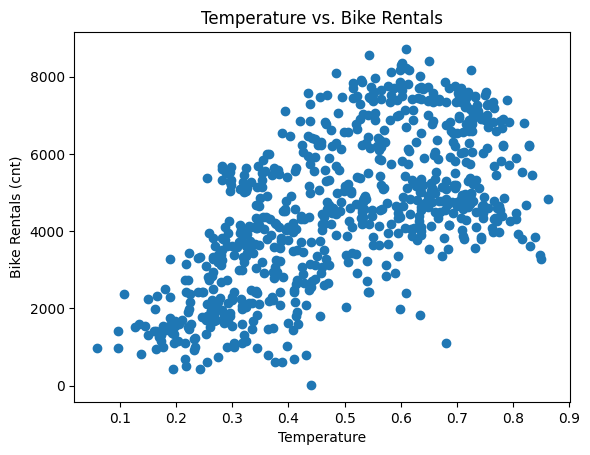

In [13]:
# Plot the bike rentals against temperature to visualize their relationship.
plt.scatter(df['temp'], df['cnt'])
plt.xlabel("Temperature")
plt.ylabel("Bike Rentals (cnt)")
plt.title("Temperature vs. Bike Rentals")
plt.show()

6. The 'windspeed' feature: create a scatter plot to show the relationship between the number of bike rentals and the windspeed.

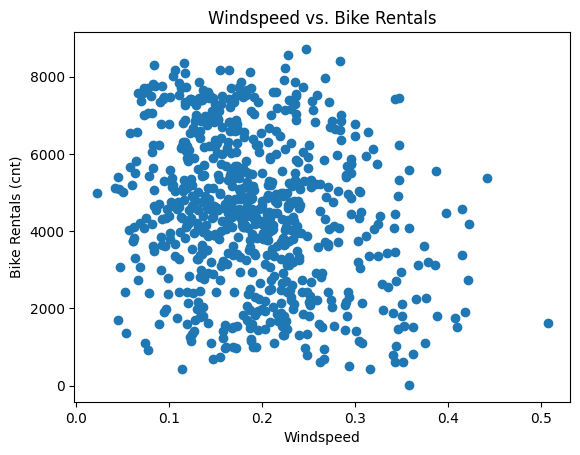

In [14]:
# Plot the bike rentals against windspeed to examine any correlation.
plt.scatter(df['windspeed'], df['cnt'])
plt.xlabel("Windspeed")
plt.ylabel("Bike Rentals (cnt)")
plt.title("Windspeed vs. Bike Rentals")
plt.show()

7. The 'year' feature: calculate and display the average bike rentals in each year.

In [15]:
# Calculate the average bike rentals for each year.
year_avg = df.groupby('year')['cnt'].mean().reset_index()

year_avg.columns = ['Year', 'Average Bike Rentals']
print("=== Average Bike Rentals for Each Year ===")
display(year_avg)

=== Average Bike Rentals for Each Year ===


,Year,Average Bike Rentals
0,2011,3405.761644
1,2012,5599.934426


8. What observations can you conclude from the data exploration?

**Answer:**

Based on the data exploration, several important patterns and observations emerge regarding the bike-sharing demand. Seasonality has a noticeable effect on usage, with the highest average rentals occurring during the fall and summer months, while demand is lower in the spring. Weather conditions also strongly influence bike usage: clear days produce the highest average number of rentals, about 4,876 rentals, whereas unfavorable weather, such as rain or snow, reduces rentals significantly to an average of about 1,803 rentals. Warmer weather generally encourages more bike usage, as comfortable outdoor conditions make cycling more appealing for both transportation and recreation. In addition, the analysis shows clear growth in usage between the two years in the dataset, with average daily rentals increasing from approximately 3,405 in 2011 to about 5,600 in 2012, indicating that the bike-sharing program became more popular over time. Finally, rental activity is slightly higher on working days and non-holidays than on weekends or holidays, suggesting that many users rely on the bikes for regular commuting or daily transportation rather than only for recreational purposes.

9. Save the final data frame as a CSV file using the `to_csv()` method. Read the [documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) of this method for more information.

In [16]:
# Save the final data frame as a CSV file.
final_filename = "bike_sharing.csv"
df.to_csv(final_filename, index=False)
print(f"✅ Final DataFrame successfully saved as \"{final_filename}\"")

# Download the final CSV file to the user's computer.
files.download(final_filename)
print(f"\n⬇️ File \"{final_filename}\" has been downloaded successfully!")

# Display the first five rows of the final data frame.
print("\n=== First 5 Rows of the bike_sharing.csv DataFrame ===")
df.head()

✅ Final DataFrame successfully saved as "bike_sharing.csv"


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


⬇️ File "bike_sharing.csv" has been downloaded successfully!

=== First 5 Rows of the bike_sharing.csv DataFrame ===


,dteday,season,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt,year
0,2011-01-01,1,1,0,6,0,2,0.344167,0.805833,0.160446,985,2011
1,2011-01-02,1,1,0,0,0,2,0.363478,0.696087,0.248539,801,2011
2,2011-01-03,1,1,0,1,1,1,0.196364,0.437273,0.248309,1349,2011
3,2011-01-04,1,1,0,2,1,1,0.200000,0.590435,0.160296,1562,2011
4,2011-01-05,1,1,0,3,1,1,0.226957,0.436957,0.186900,1600,2011
